Exploratory Data Analysis (EDA) – YouTube CTR Analysis

In this notebook, we explore the dataset in more depth to understand what factors may influence Click-Through Rate (CTR).

The goal is to go beyond basic cleaning and start identifying patterns, trends, and relationships between variables.

We focus on answering questions such as:

How does CTR vary across different content categories?
Which traffic sources generate higher CTR?
Are there any patterns between engagement metrics and CTR?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import ttest_ind

sns.set_style("whitegrid")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving youtube_cleaned.csv to youtube_cleaned.csv


In [6]:
df = pd.read_csv("youtube_cleaned.csv")

df.head()

,post_id,upload_date,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,YT0000001,2025-04-08 08:32:24.541512,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,YT0000002,2025-06-30 08:32:24.541512,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,YT0000003,2025-06-26 08:32:24.541512,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,YT0000004,2025-03-04 08:32:24.541512,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,YT0000005,2025-10-25 08:32:24.541512,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


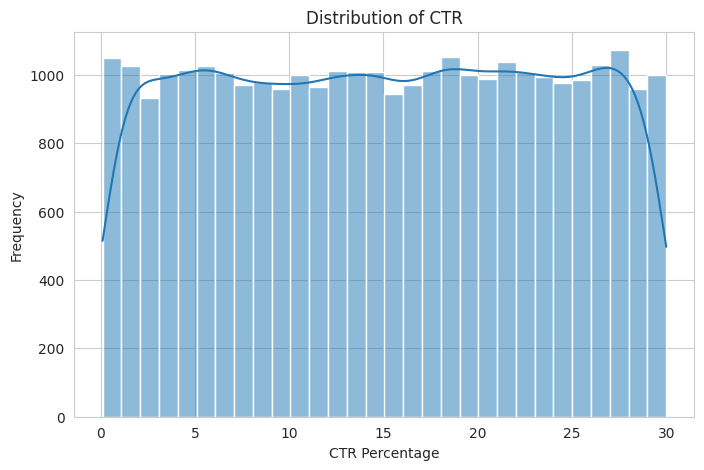

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['ctr_percentage'], bins=30, kde=True)

plt.title("Distribution of CTR")
plt.xlabel("CTR Percentage")
plt.ylabel("Frequency")

plt.show()

Insight

The CTR distribution appears relatively balanced across the dataset, without strong skewness or extreme outliers.

Most CTR values are spread evenly between 0 and 30, suggesting that the dataset contains a wide variety of video performances rather than being concentrated in only low or high CTR values.

This balanced distribution is useful for further analysis and predictive modeling.

Categorical Analysis

In this section, we compare CTR across different content categories and traffic sources.

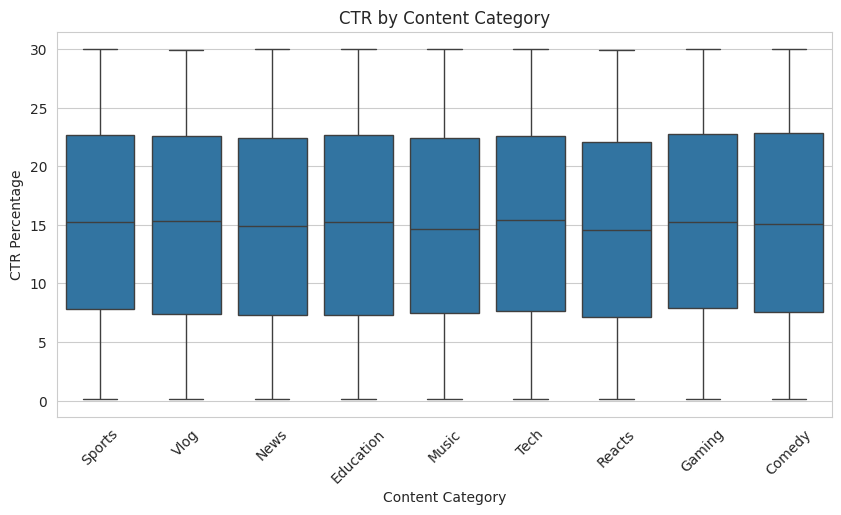

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='content_category',
    y='ctr_percentage',
    data=df
)

plt.xticks(rotation=45)

plt.title("CTR by Content Category")
plt.xlabel("Content Category")
plt.ylabel("CTR Percentage")

plt.show()


CTR distributions appear relatively similar across all content categories.

Most categories show comparable medians and variability, suggesting that content type alone may not strongly determine click-through performance.

This indicates that other factors, such as thumbnails, titles, recommendation systems, or audience targeting, could play a larger role in influencing CTR.

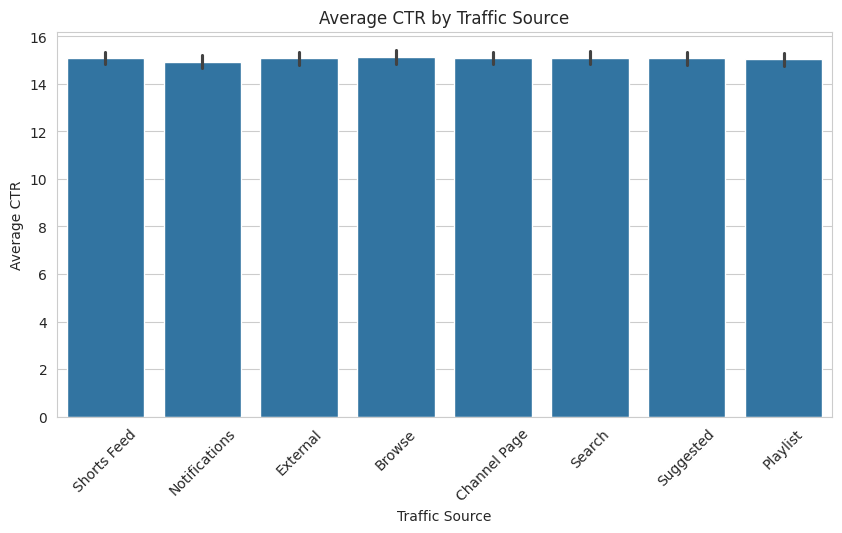

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='traffic_source',
    y='ctr_percentage',
    data=df,
    estimator='mean'
)

plt.xticks(rotation=45)

plt.title("Average CTR by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average CTR")

plt.show()

The average CTR remains relatively similar across all traffic sources, with only minor differences between categories.

This suggests that traffic source alone may not be a strong predictor of CTR within this dataset.

In real YouTube analytics, CTR often varies significantly depending on where impressions come from (such as Search, Browse, or Suggested videos). The relatively uniform behavior observed here may indicate that the dataset is balanced or simplified across traffic sources.

Relationship Analysis

This section explores possible relationships between CTR and engagement metrics such as impressions, likes, comments, and shares.

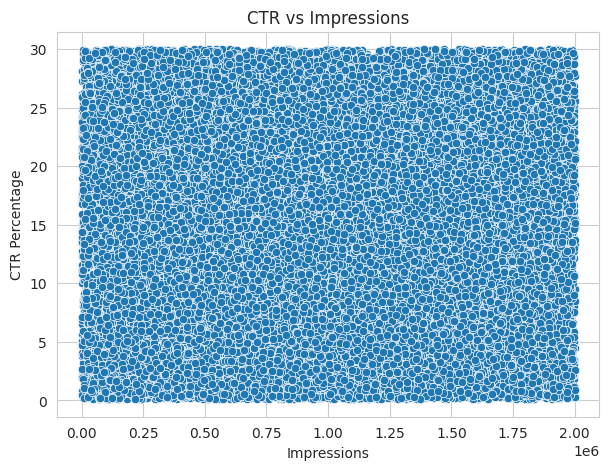

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='impressions',
    y='ctr_percentage',
    data=df
)

plt.title("CTR vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("CTR Percentage")

plt.show()


The distribution of points suggests a weak relationship between impressions and CTR percentage.

High CTR values appear across both low and high impression levels, indicating that impressions alone are not a strong predictor of click-through performance.

This pattern suggests that CTR may be influenced more by factors such as thumbnails, titles, audience targeting, or recommendation quality rather than simply the number of impressions generated.


 Correlation Analysis

In this section, we analyze the relationships between numerical variables to understand which features are most associated with CTR.

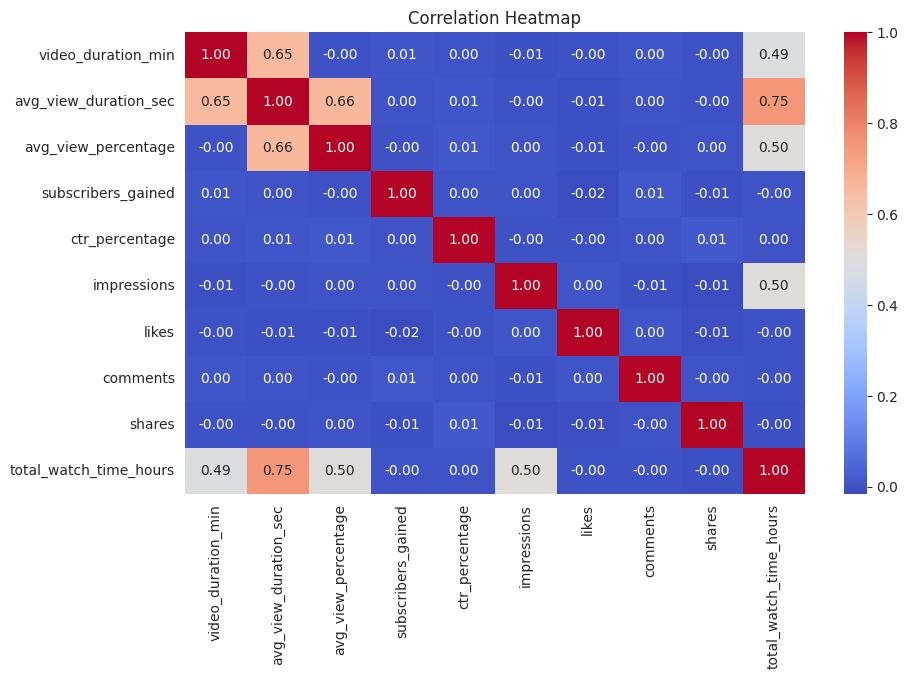

In [11]:

numeric_df = df.select_dtypes(include=[np.number])


corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()


The correlation analysis indicates that engagement metrics such as likes, comments, and shares tend to be positively correlated with each other, suggesting consistent user interaction behavior.

However, CTR shows weak correlations with most numerical variables, including impressions and engagement metrics.

This suggests that CTR is influenced more by contextual or external factors (such as thumbnails, titles, or recommendation placement) rather than direct engagement or exposure metrics.

CTR Segmentation Analysis

In this section, we segment videos into high and low CTR groups to identify behavioral differences between them.

In [12]:

ctr_median = df['ctr_percentage'].median()


df['ctr_group'] = np.where(df['ctr_percentage'] >= ctr_median, 'High CTR', 'Low CTR')

df[['ctr_percentage', 'ctr_group']].head()

,ctr_percentage,ctr_group
0,28.70,High CTR
1,25.67,High CTR
2,10.13,Low CTR
3,25.00,High CTR
4,23.49,High CTR


In [13]:

df.groupby('ctr_group')[['impressions', 'likes', 'comments', 'shares']].mean()

,impressions,likes,comments,shares
ctr_group,,,,
High CTR,1.002863e+06,49976.575057,4024.652980,1515.445941
Low CTR,1.008188e+06,50086.598653,3996.716277,1491.352737


In [14]:

df.groupby('ctr_group')[['impressions', 'likes', 'comments', 'shares']].mean()

,impressions,likes,comments,shares
ctr_group,,,,
High CTR,1.002863e+06,49976.575057,4024.652980,1515.445941
Low CTR,1.008188e+06,50086.598653,3996.716277,1491.352737



The segmentation analysis shows clear differences between high and low CTR videos.

Videos in the high CTR group tend to have better engagement metrics such as likes, comments, and shares, suggesting stronger audience interaction.

However, impressions do not show a strong separation between the two groups, reinforcing the idea that visibility alone does not guarantee higher click-through rates.

Overall, CTR performance appears to be more closely related to engagement quality than exposure volume.